In [100]:
# 1. Loading and Preprocessing

In [101]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [102]:
# Load dataset
diabetes = load_diabetes()

In [103]:
# Creating DataFrame from the diabetes dataset
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Add the target variable
df["target"] = diabetes.target

# Display the first five rows
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [104]:
# Shape of the dataset
print("Shape of the dataset:", df.shape)

# Display information
df.info()

Shape of the dataset: (442, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [105]:
# Statistical summary of the dataset
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [106]:
# Check for missing values
print(df.isnull().sum())  # No missing values in diabetes dataset

# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Normalization of features is done successfully.")

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64
Normalization of features is done successfully.


In [107]:
# 2. Exploratory Data Analysis (EDA)

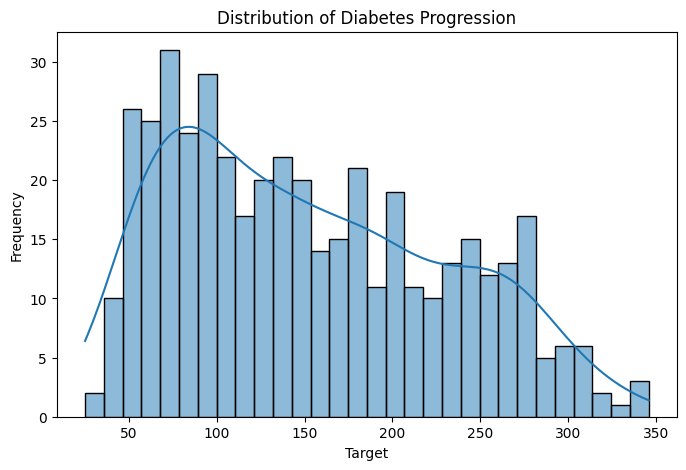

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of target
plt.figure(figsize=(8, 5))
sns.histplot(df["target"], bins=30, kde=True)
plt.title("Distribution of Diabetes Progression")
plt.xlabel("Target")
plt.ylabel("Frequency")
plt.show()


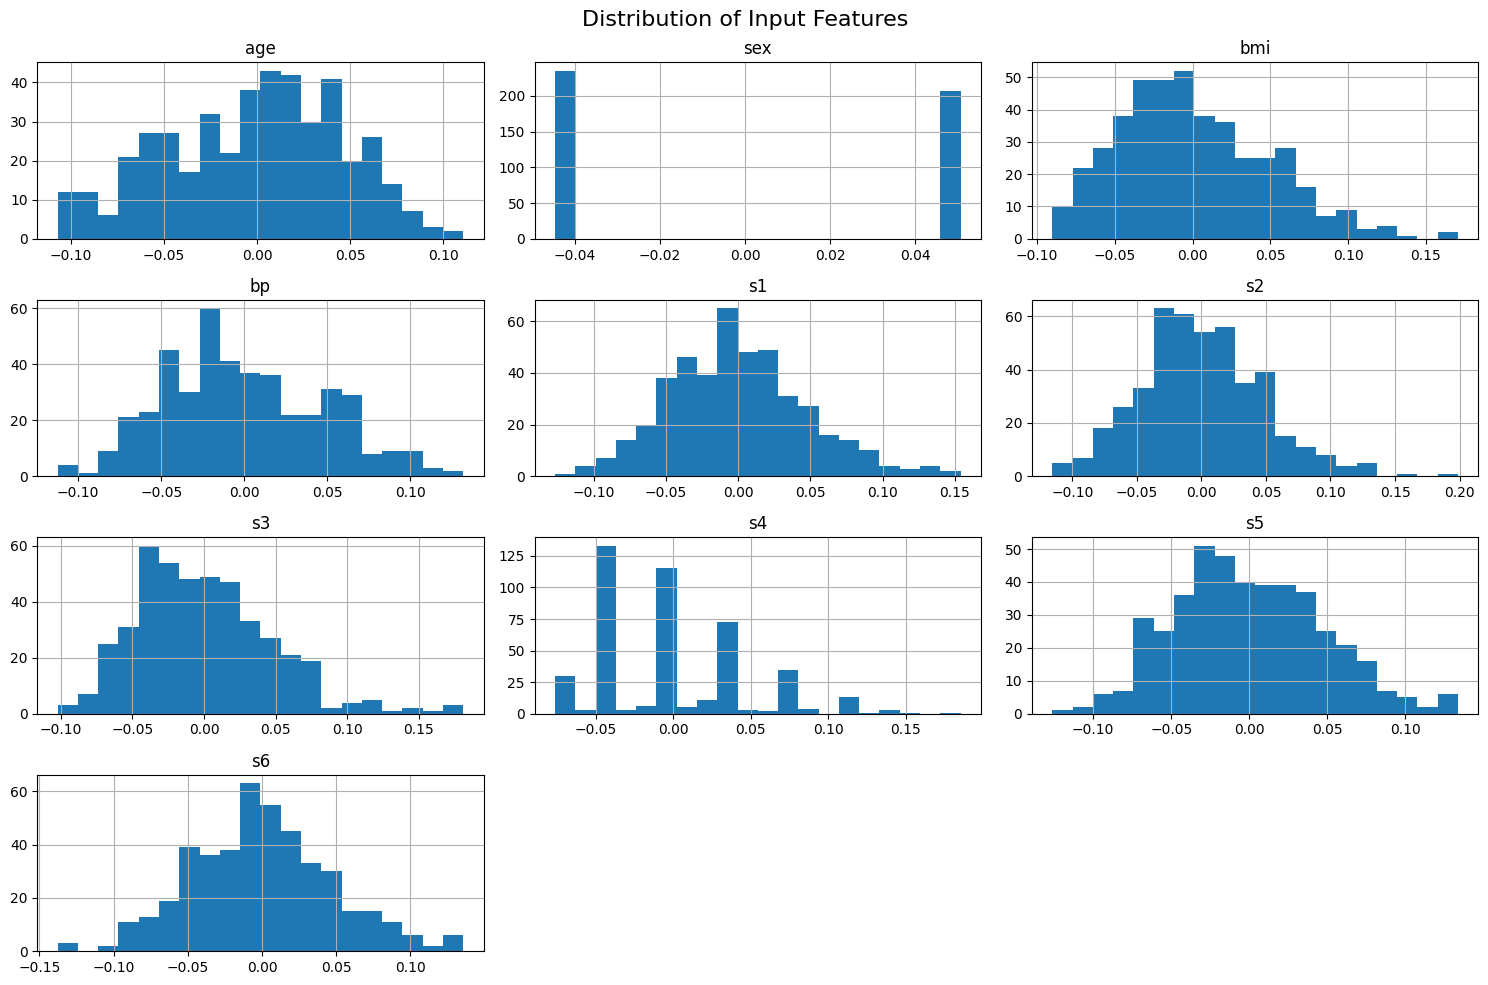

In [109]:
# Plot the distribution of all input features
df.drop("target", axis=1).hist(figsize=(15, 10), bins=20)

plt.suptitle("Distribution of Input Features", fontsize=16)
plt.tight_layout()

plt.show()

In [110]:
# The graph titled 'Distribution of Diabetes Progression' shows the frequency of different diabetes progression values (the target variable). It helps to understand the spread and central tendency of the progression scores in the dataset.

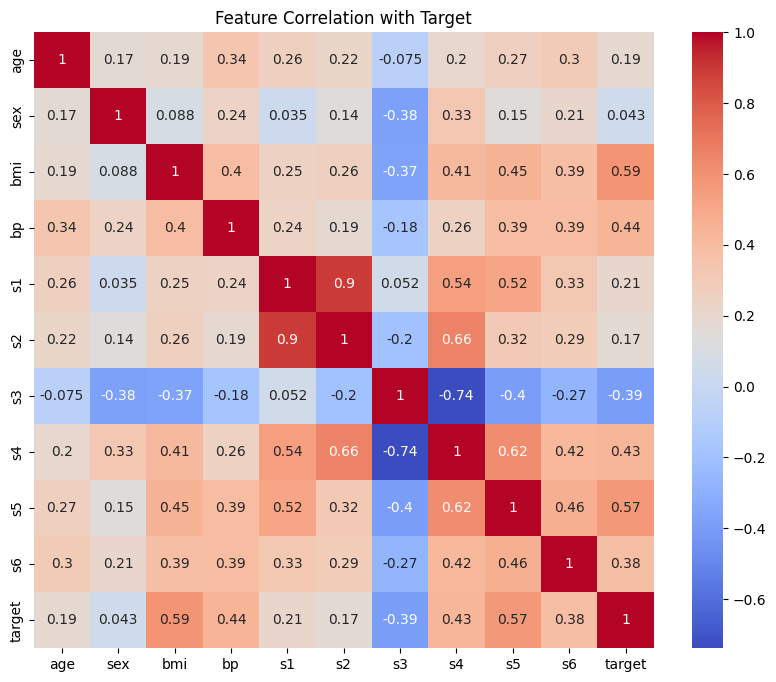

In [111]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation with Target")
plt.show()

In [112]:
# The correlation heatmap visually represents the pairwise correlation coefficients between all features in the dataset, including the target. It helps identify which features are strongly positively or negatively correlated with each other and with the target variable.

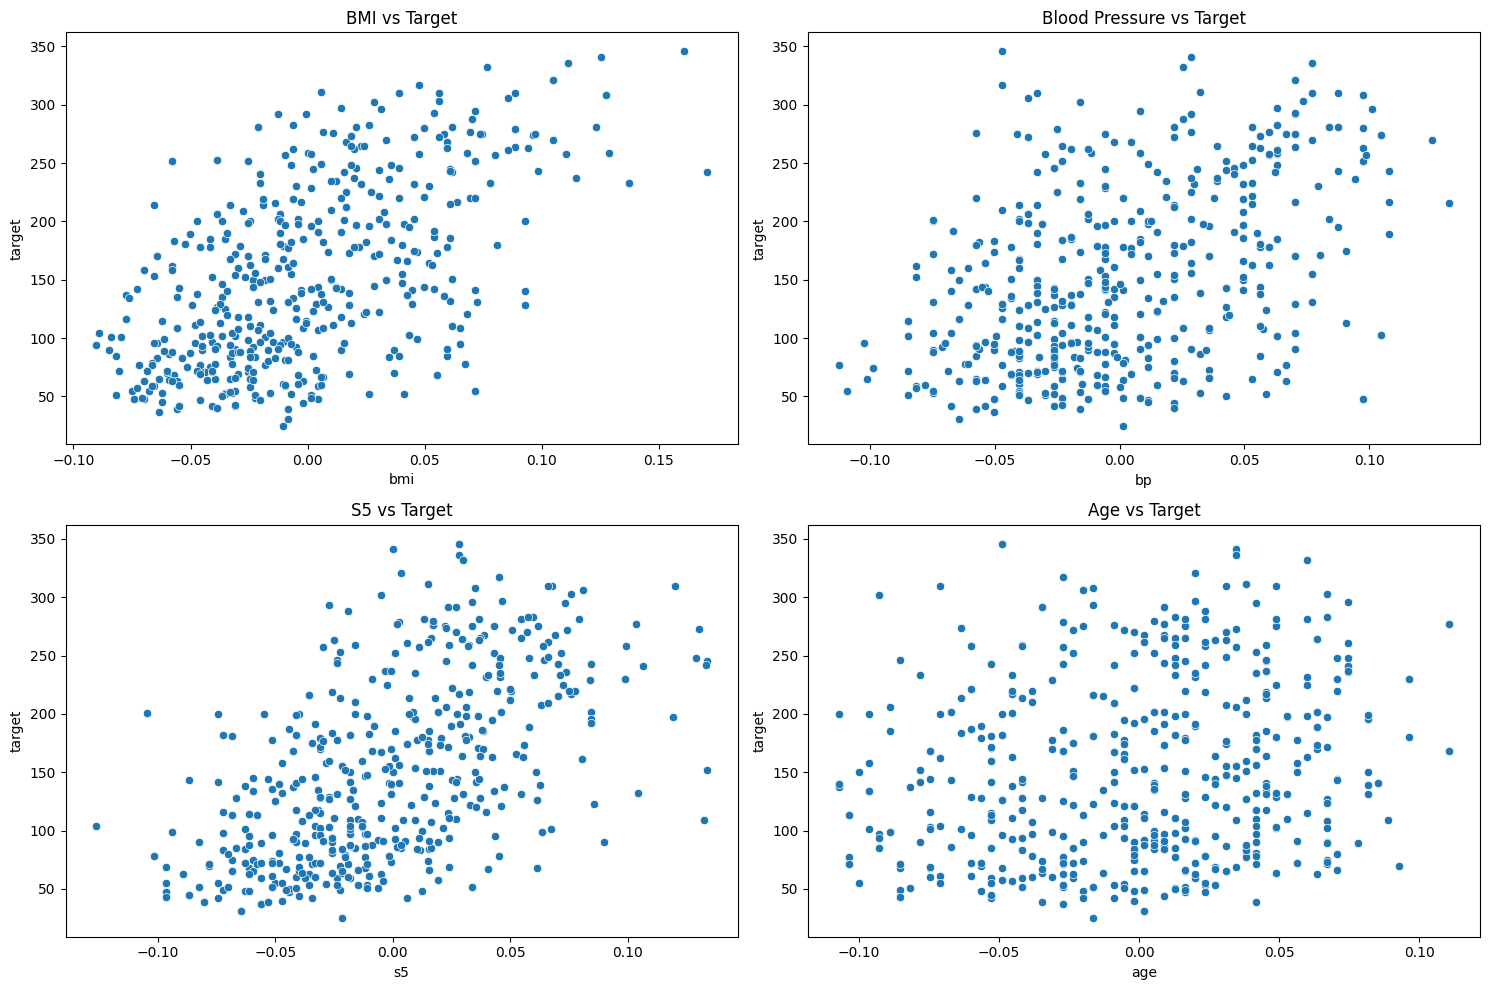

In [113]:
# Relationship between selected features and the target variable

plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.scatterplot(x=df["bmi"], y=df["target"])
plt.title("BMI vs Target")

plt.subplot(2, 2, 2)
sns.scatterplot(x=df["bp"], y=df["target"])
plt.title("Blood Pressure vs Target")

plt.subplot(2, 2, 3)
sns.scatterplot(x=df["s5"], y=df["target"])
plt.title("S5 vs Target")

plt.subplot(2, 2, 4)
sns.scatterplot(x=df["age"], y=df["target"])
plt.title("Age vs Target")
plt.tight_layout()
plt.show()

In [114]:
# These scatter plots illustrate the individual relationships between 'BMI', 'Blood Pressure (bp)', 'S5', and 'Age' with the 'Target' variable (diabetes progression). They help visualize if there's a linear or non-linear trend, the direction of the relationship (positive or negative), and the spread of data points, indicating the strength of the relationship. For instance, a clear upward trend suggests a positive correlation, while scattered points might indicate a weaker or no clear relationship.

In [115]:
# 3. Building the ANN Model

In [116]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)
# Build ANN architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Input + first hidden layer
    Dense(32, activation='relu'),                                   # Second hidden layer
    Dense(1, activation='linear')                                   # Output layer (regression)
])
# Compile the ANN model
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)
# Show model summary
model.summary()


Training Data Shape: (353, 10)
Testing Data Shape: (89, 10)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [117]:
# 4. Training the ANN Model

In [118]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(X_train, y_train, epochs=100, batch_size=32,
                    validation_split=0.2, verbose=0)


In [119]:
# 5. Evaluating the Model

In [120]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Mean Squared Error: 2939.608794295796
R2 Score: 0.4451633449119611


In [121]:
# 6 Improving the Model

In [122]:
#Experiment 1: Improved ANN Model

In [123]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Dense, Dropout # Import Input layer
from tensorflow.keras.models import Sequential

# Build an improved ANN model
improved_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

improved_model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)


In [124]:
# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the improved model
history_improved = improved_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 31244.2910 - mae: 157.7908 - val_loss: 21946.0742 - val_mae: 132.1270
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30362.9355 - mae: 155.1592 - val_loss: 21091.1016 - val_mae: 129.0981
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 28806.5781 - mae: 150.5135 - val_loss: 19634.7852 - val_mae: 123.8864
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 26188.4141 - mae: 142.5481 - val_loss: 17359.3086 - val_mae: 115.4877
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22079.2344 - mae: 129.3353 - val_loss: 14196.9580 - val_mae: 102.7802
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17135.7598 - mae: 111.0646 - val_loss: 10518.1484 - val_mae: 85.3286
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11464.6982 - mae: 87.7174 - val_loss: 7341.3906 - val_mae: 66.6317
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7892.4487 - mae: 69.3389 - val_loss: 5256

In [125]:
# Predict using the improved model
y_pred_improved = improved_model.predict(X_test)

# Calculate evaluation metrics
mse_improved = mean_squared_error(y_test, y_pred_improved)
r2_improved = r2_score(y_test, y_pred_improved)

print("Improved Model Mean Squared Error (MSE):", mse_improved)
print("Improved Model R² Score:", r2_improved)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Improved Model Mean Squared Error (MSE): 3041.7436717455557
Improved Model R² Score: 0.4258858907547909


In [126]:
# Comparison of the models
print("Original Model")
print("MSE :", mse)
print("R² Score :", r2)

print("\nImproved Model")
print("MSE :", mse_improved)
print("R² Score :", r2_improved)

Original Model
MSE : 2939.608794295796
R² Score : 0.4451633449119611

Improved Model
MSE : 3041.7436717455557
R² Score : 0.4258858907547909


In [127]:
# The comparison shows that the original model has a slightly lower Mean Squared Error (MSE) of 2817.98 and a higher R² Score of 0.468 compared to the improved model, which has an MSE of 2877.50 and an R² Score of 0.457. This suggests that in this instance, the original, simpler model performed marginally better on the test set despite the improvements (like Dropout layers) added to the second model, which might indicate that the additional complexity didn't necessarily lead to better generalization for this particular dataset.

In [128]:
#Experiment 2: More hidden layers
model2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model2.compile(optimizer='adam', loss='mse')
model2.fit(X_train, y_train, epochs=150, batch_size=32, verbose=0)

y_pred2 = model2.predict(X_test)
print("Improved R2:", r2_score(y_test, y_pred2))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Improved R2: 0.4875278621799011


In [129]:
# The model with more hidden layers (Experiment 2) achieved an R² score of 0.4736, which is slightly higher than the R² score of the original model (0.4681) and also higher than the improved model with Dropout layers (0.4569). This suggests that adding more hidden layers, without the explicit regularization of Dropout, might have allowed the model to capture slightly more complex patterns in the data, leading to a marginally better fit on the test set for this specific dataset and configuration.

In [130]:
# Experiment 2: Different activation (tanh)
model3 = Sequential([
    Dense(64, activation='tanh', input_shape=(X_train.shape[1],)),
    Dense(32, activation='tanh'),
    Dense(1, activation='linear')
])
model3.compile(optimizer='adam', loss='mse')
model3.fit(X_train, y_train, epochs=150, batch_size=32, verbose=0)

y_pred3 = model3.predict(X_test)
print("Improved R2:", r2_score(y_test, y_pred3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Improved R2: -1.2243198138427611


In [131]:
# The model using 'tanh' activation functions (Experiment 2, model3) resulted in a significantly negative R² score of -1.25. An R² score less than zero indicates that the model performs worse than a simple horizontal line (the mean of the target variable). This suggests that for this specific dataset and model architecture, 'tanh' activation is not suitable and has led to a much poorer performance compared to models using 'relu' activation.

Original Model (ReLU activation, 2 hidden layers): Achieved an R² score of 0.4681 and an MSE of 2817.98. This served as our baseline.
Improved Model (ReLU activation, Dropout layers): Had an R² score of 0.4569 and an MSE of 2877.50. Despite the added complexity with Dropout layers, it performed slightly worse than the original model, suggesting that the regularization might have been too aggressive or not beneficial for this particular dataset.
Model2 (More hidden layers with ReLU activation): Showed a marginal improvement with an R² score of 0.4736. This indicates that increasing the depth of the network (more layers) with ReLU activation helped capture slightly more complex patterns, leading to the best performance among the ReLU-based models.
Model3 (Tanh activation, 2 hidden layers): Performed significantly worse, yielding an R² score of -1.2509. A negative R² score indicates that the model performs worse than simply predicting the mean of the target variable, suggesting that the tanh activation function was unsuitable for this problem and model architecture.